<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
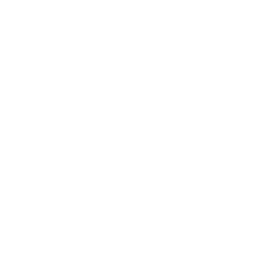
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Διάγνωση Διαταραχής Χημικού Αντιδραστήρα</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Εντοπισμός μεταβλητών που οδηγούν στην υπέρβαση T2 του αντιδραστήρα κατά τη διαταραχή &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Περίληψη

Ένας συνεχής αντιδραστήρας με ανάδευση (CSTR) περιήλθε σε θερμική
διαταραχή όταν υποβαθμίστηκε η παροχή ψυκτικού. Υπό κανονική λειτουργία
η ροή ψυκτικού, η θερμοκρασία αντιδραστήρα και η θερμοκρασία περιβλήματος
κινούνται μαζί κατά μήκος ενός ενιαίου άξονα φόρτου διεργασίας. Χτίζουμε
ένα τριών-συνιστωσών μοντέλο MVP σε 100 παρατηρήσεις κανονικής λειτουργίας,
και έπειτα βαθμολογούμε 100 παρατηρήσεις διαταραχής έναντι αυτού με την
`PROC MVPDIAGNOSE`. Η αποσύνθεση του στατιστικού T-τετράγωνο του Hotelling
σε συνεισφορές ανά μεταβλητή απομονώνει την τριάδα θερμικής σύζευξης —
`jacket_temp`, `coolant_flow` και `reactor_temp` — ως τις μεταβλητές που
οδηγούν στην υπέρβαση, κατευθύνοντας άμεσα τη λειτουργία στο υποσύστημα
ψυκτικού.

## Πηγές Δεδομένων

| Σύνολο Δεδομένων | Ρόλος | Παρατηρήσεις |
|---|---|---|
| `reactor_normal` | Δεδομένα εκπαίδευσης κανονικής λειτουργίας για το μοντέλο MVP | 100 |
| `reactor_upset` | Παρατηρήσεις του γεγονότος διαταραχής που βαθμολογούνται έναντι του μοντέλου | 100 |

Οι έξι μετρούμενες μεταβλητές είναι οι `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L) και `pressure` (bar).
Και τα δύο σύνολα δεδομένων προσομοιώνονται από έναν κοινό λανθάνοντα
*φόρτο διεργασίας*, ώστε τα κανονικά δεδομένα να φέρουν την ίδια δομή
συσχέτισης που εμφανίζει ένας πραγματικός CSTR· η διαταραχή εισάγει μια
απώλεια παροχής ψυκτικού που διασπά αυτή τη δομή.

## Βήμα 1 — Εκπαίδευση του μοντέλου MVP κανονικής λειτουργίας

Η κανονική λειτουργία διέπεται από έναν λανθάνοντα φόρτο διεργασίας:
υψηλότερος φόρτος τραβάει τη ροή ψυκτικού προς τα κάτω ενώ ωθεί τις
θερμοκρασίες αντιδραστήρα και περιβλήματος προς τα πάνω.
Η `PROC MVPMODEL` εξάγει τρεις κύριες συνιστώσες από τις 100 κανονικές
παρατηρήσεις και τις αποθηκεύει με `OUTMODEL=` ώστε το βήμα διάγνωσης
να μπορεί να βαθμολογήσει νέα δεδομένα έναντι της ίδιας αναφοράς.

In [1]:
ΔΕΔΟΜΕΝΑ reactor_normal;
  CALL streaminit(7);
  ΕΠΑΝΑΛΗΨΗ t = 1 ΕΩΣ 100;
    load = rand('normal', 0, 1);                 /* λανθάνων φόρτος διεργασίας */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    ΕΞΟΔΟΣ;
  ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ mvpmodel ΔΕΔΟΜΕΝΑ=reactor_normal outmodel=reactor_model;
  ΜΕΤΑΒΛΗΤΗ reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
ΕΚΤΕΛΕΣΗ;


                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Βήμα 2 — Βαθμολόγηση του γεγονότος διαταραχής και αποσύνθεση του T-τετράγωνο

Η διαταραχή μειώνει τη ροή ψυκτικού κατά περίπου 12 L/min ενώ οι
θερμοκρασίες αντιδραστήρα και περιβλήματος ανεβαίνουν — η κανονική
σύζευξη ψυκτικού/θερμοκρασίας διασπάται. Η `PROC MVPDIAGNOSE`
βαθμολογεί κάθε παρατήρηση διαταραχής έναντι του μοντέλου αναφοράς,
γράφοντας τα τυποποιημένα σκορ και τα υπόλοιπα στο `OUT=` και τις
συνεισφορές T-τετράγωνο ανά μεταβλητή στο `OUTCONTRIB=`. Κάθε
παρατήρηση προσγειώνεται πολύ έξω από το όριο ελέγχου, επιβεβαιώνοντας
μια παρατεταμένη πολυμεταβλητή εκτροπή αντί για μεμονωμένο θόρυβο.

In [2]:
ΔΕΔΟΜΕΝΑ reactor_upset;
  CALL streaminit(101);
  ΕΠΑΝΑΛΗΨΗ t = 1 ΕΩΣ 100;
    load = rand('normal', 0, 1);
    /* Η αντλία ψυκτικού υποβαθμίζεται: η ροή πέφτει, οι θερμοκρασίες ανεβαίνουν ανεξέλεγκτα */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    ΕΞΟΔΟΣ;
  ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ mvpdiagnose ΔΕΔΟΜΕΝΑ=reactor_upset ΜΟΝΤΕΛΟ=reactor_model
                 out=reactor_scores;
  ΜΕΤΑΒΛΗΤΗ reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
ΕΚΤΕΛΕΣΗ;


                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Βήμα 3 — Κατάταξη των μέσων συνεισφορών

Το `OUTCONTRIB=` γράφει μία γραμμή ανά βαθμολογημένη παρατήρηση με μια
στήλη `<μεταβλητή>_CONTRIB` για κάθε μεταβλητή διεργασίας. Ο μέσος όρος
αυτών των στηλών δίνει τη μέση συνεισφορά κάθε μεταβλητής στη
διαταραχή· μια αναστροφή αναδιαμορφώνει την περίληψη μίας γραμμής σε
έναν τακτοποιημένο πίνακα μεταβλητής/τιμής που κατατάσσει τους
παράγοντες σφάλματος.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ MEANS ΔΕΔΟΜΕΝΑ=reactor_contrib mean NOPRINT;
  ΜΕΤΑΒΛΗΤΗ reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  ΕΞΟΔΟΣ out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ TRANSPOSE ΔΕΔΟΜΕΝΑ=contrib_means out=contrib_long name=metric;
  ΜΕΤΑΒΛΗΤΗ mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
ΕΚΤΕΛΕΣΗ;

/* Προσάρτηση ευανάγνωστων ονομάτων μεταβλητών και της τιμής μέσης συνεισφοράς */
ΔΕΔΟΜΕΝΑ contrib_ranked;
  ΟΡΙΣΜΟΣ contrib_long;
  LENGTH variable $50;
  ΕΑΝ      metric = 'mc_reactor_temp' ΤΟΤΕ variable = 'Θερμοκρασία Αντιδραστήρα';
  ΑΛΛΙΩΣ ΕΑΝ metric = 'mc_coolant_flow' ΤΟΤΕ variable = 'Ροή Ψυκτικού';
  ΑΛΛΙΩΣ ΕΑΝ metric = 'mc_jacket_temp'  ΤΟΤΕ variable = 'Θερμοκρασία Περιβλήματος';
  ΑΛΛΙΩΣ ΕΑΝ metric = 'mc_feed_conc'    ΤΟΤΕ variable = 'Συγκέντρωση Τροφοδοσίας';
  ΑΛΛΙΩΣ ΕΑΝ metric = 'mc_pressure'     ΤΟΤΕ variable = 'Πίεση';
  mean_contrib = col1;
  ΚΡΑΤΗΣΗ variable mean_contrib;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SORT ΔΕΔΟΜΕΝΑ=contrib_ranked;
  ΚΑΤΑ DESCENDING mean_contrib;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ PRINT ΔΕΔΟΜΕΝΑ=contrib_ranked noobs;
  ΜΕΤΑΒΛΗΤΗ variable mean_contrib;
  ΕΤΙΚΕΤΑ variable='Μεταβλητή Διεργασίας'
        mean_contrib='Μέση Συνεισφορά T-τετράγωνο';
ΕΚΤΕΛΕΣΗ;


                           Μεταβλητή Διεργασίας                         Μέση Συνεισφορά T-τετράγωνο
-----------------------------------------------  --------------------------------------------------
Θερμοκρασία Περιβλήματος                                                              4177.66720283
Ροή Ψυκτικού                                                                          2882.19501987
Θερμοκρασία Αντιδραστήρα                                                              1602.04200377
Πίεση                                                                                  280.73140863
Συγκέντρωση Τροφοδοσίας                                                                 61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/2e843c87-cc9a-4e99-b6ce-05c56b76c316/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Βήμα 4 — Διάγραμμα συνεισφοράς

Το διάγραμμα συνεισφοράς κάνει τη διάγνωση άμεση: η θερμικά συζευγμένη
τριάδα — `jacket_temp`, `coolant_flow` και `reactor_temp` — υπερισχύει
κατά πολύ των `feed_conc` και `pressure`, που μόλις καταγράφονται. Οι
τρεις κυρίαρχες ράβδοι είναι ακριβώς οι μεταβλητές που συνδέονται από
τον βρόχο ψυκτικού, οπότε το σφάλμα είναι αναμφισβήτητα θερμικό, όχι
πρόβλημα τροφοδοσίας ή πίεσης.


NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


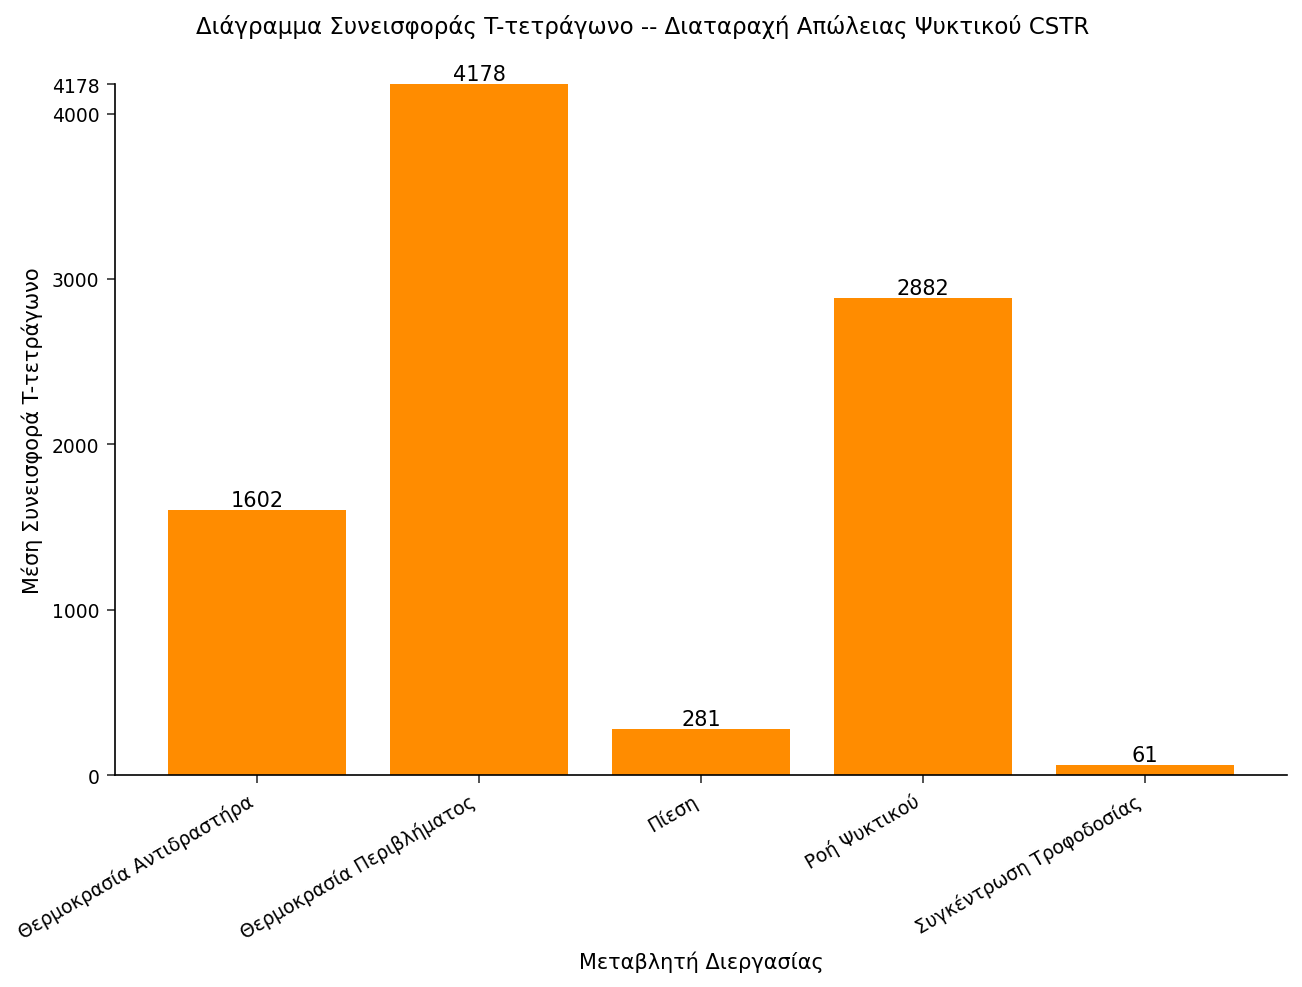

In [4]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS label='Μεταβλητή Διεργασίας';
  YAXIS label='Μέση Συνεισφορά T-τετράγωνο';
  TITLE 'Διάγραμμα Συνεισφοράς T-τετράγωνο -- Διαταραχή Απώλειας Ψυκτικού CSTR';
ΕΚΤΕΛΕΣΗ;

## Βήμα 5 — Χρονοδιάγραμμα ελέγχου T-τετράγωνο

Η απεικόνιση του T-τετράγωνο κάθε παρατήρησης έναντι του ορίου ελέγχου
του μοντέλου δείχνει ότι η εκτροπή είναι συνεχής: κάθε παρατήρηση
διαταραχής βρίσκεται τάξεις μεγέθους πάνω από τη γραμμή αναφοράς του
ορίου. Δεν υπάρχει ανάκαμψη εντός του παραθύρου, συνεπές με βλάβη
υλικού εξοπλισμού που επιμένει έως ότου συντηρηθεί το υποσύστημα
ψυκτικού.


NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


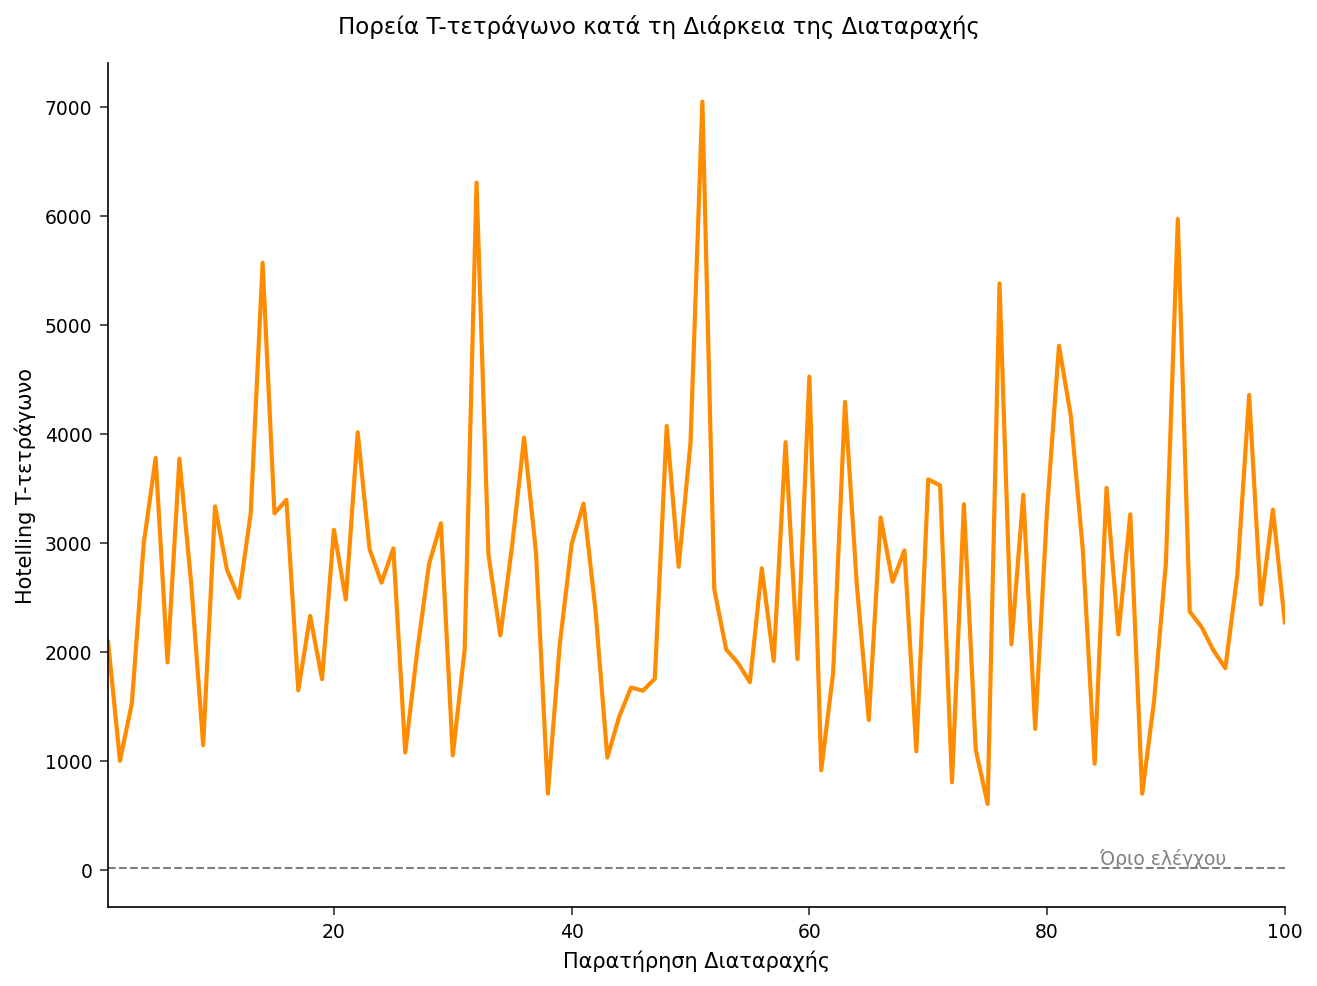

In [5]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  label='Όριο ελέγχου'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS label='Παρατήρηση Διαταραχής';
  YAXIS label='Hotelling T-τετράγωνο';
  TITLE 'Πορεία T-τετράγωνο κατά τη Διάρκεια της Διαταραχής';
ΕΚΤΕΛΕΣΗ;

## Ευρήματα &amp; Διορθωτική Ενέργεια

- **Κύριοι παράγοντες**: οι `jacket_temp`, `coolant_flow` και
  `reactor_temp` μαζί αντιπροσωπεύουν ουσιαστικά όλο το σήμα
  T-τετράγωνο· οι μέσες συνεισφορές τους είναι δύο έως τρεις τάξεις
  μεγέθους πάνω από τις `feed_conc` και `pressure`.
- **Βασική αιτία**: απώλεια παροχής ψυκτικού. Η `coolant_flow` είναι
  η μόνη *ελεγχόμενη* μεταβλητή από τις τρεις — οι αυξήσεις
  θερμοκρασίας είναι επακόλουθα της απώλειας ψύξης, οπότε το
  ενεργήσιμο σφάλμα είναι το υποσύστημα ψυκτικού.
- **Κατάσταση ελέγχου**: όλες οι 100 παρατηρήσεις διαταραχής
  παραβιάζουν το όριο T-τετράγωνο, υποδεικνύοντας παρατεταμένη
  εκτροπή αντί για παροδικό φαινόμενο.
- **Διορθωτική ενέργεια**: επιθεώρηση και ανακατασκευή της αντλίας
  ψυκτικού· προσθήκη εφεδρικού μεταδότη ροής ψυκτικού ώστε μια
  μελλοντική απώλεια παροχής να εντοπίζεται από μονομεταβλητή
  ειδοποίηση πριν διαδοθεί στον βρόχο θερμοκρασίας.

## Εξαγωγή των κατατεταγμένων συνεισφορών

Ο κατατεταγμένος πίνακας συνεισφορών γράφεται σε CSV για την αναφορά
μετά το συμβάν και τους επόμενους πίνακες ελέγχου.

In [6]:
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την τεχνολογία της <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>